In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

In [2]:
# Set style for academic papers
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [3]:
# Data for all tasks - Intra-dataset and Intra-task results
data = {
    'NLU': {
        'intra_dataset': {  # ArabicMMLU
            'AceGPT-7B': {'Base': [37.51, 31.23, 31.41, 39.10, 36.52], 
                         'Chat': [47.10, 28.26, 31.83, 42.54, 40.72],
                         'Tuned': [56.24, 51.54, 43.63, 56.79, 54.60]},
            'LLaMA3.1-8B': {'Base': [48.74, 29.60, 31.74, 46.32, 43.34],
                            'Instruct': [54.64, 28.96, 32.92, 53.27, 50.34],
                            'Tuned': [57.25, 54.75, 51.13, 56.77, 56.98]}
        },
        'intra_task': {  # ArabicMMLU → Belebele
            'AceGPT-7B': {'Base': [35.67, 24.00, 32.78, 26.33, 22.78],
                         'Chat': [39.67, 27.22, 42.56, 39.89, 26.00],
                         'Tuned': [43.78, 30.00, 46.56, 44.78, 40.00]},
            'LLaMA3.1-8B': {'Base': [52.89, 26.22, 50.11, 49.11, 45.00],
                            'Instruct': [58.67, 22.56, 57.56, 53.56, 52.67],
                            'Tuned': [58.56, 35.44, 56.00, 56.56, 57.00]}
        }
    },
    'NLI': {
        'intra_dataset': {  # ArEntail
            'AceGPT-7B': {'Base': [51.5, 50.8, 50.0, 50.0, 51.9],
                         'Chat': [50.0, 52.7, 50.0, 50.0, 51.0],
                         'Tuned': [82.9, 77.1, 64.4, 74.9, 79.2]},
            'LLaMA3.1-8B': {'Base': [50.6, 50.2, 51.6, 50.0, 51.0],
                            'Instruct': [56.3, 73.4, 64.6, 50.6, 65.9],
                            'Tuned': [90.3, 91.1, 91.6, 91.9, 90.5]}
        },
        'intra_task': {  # ArEntail → ArabicTE
            'AceGPT-7B': {'Base': [44.08, 57.35, 49.53, 49.76, 52.13],
                         'Chat': [50.24, 59.24, 47.16, 52.13, 55.45],
                         'Tuned': [60.19, 52.13, 66.59, 52.13, 53.08]},
            'LLaMA3.1-8B': {'Base': [51.66, 53.79, 52.13, 52.13, 52.13],
                            'Instruct': [52.84, 53.32, 52.37, 56.40, 55.45],
                            'Tuned': [58.06, 52.13, 55.45, 54.03, 56.40]}
        }
    },
    'Dialect_ID': {
        'intra_dataset': {  # AraBench
            'AceGPT-7B': {'Base': [21.86, 14.59, 13.08, 21.07, 13.08],
                         'Chat': [20.89, 14.79, 14.48, 15.87, 13.08],
                         'Tuned': [45.12, 45.82, 39.84, 51.46, 27.25]},
            'LLaMA3.1-8B': {'Base': [15.69, 20.12, 14.46, 14.31, 13.02],
                            'Instruct': [15.81, 25.36, 14.37, 14.24, 13.02],
                            'Tuned': [88.39, 89.05, 89.24, 89.19, 88.91]}
        },
        'intra_task': {  # AraBench → Arabic Dialects Dataset
            'AceGPT-7B': {'Base': [17.64, 16.13, 19.88, 16.87, 16.13],
                         'Chat': [17.72, 16.13, 16.41, 19.09, 16.13],
                         'Tuned': [52.62, 44.38, 26.03, 20.96, 43.21]},
            'LLaMA3.1-8B': {'Base': [23.06, 16.13, 18.07, 19.71, 16.13],
                            'Instruct': [44.87, 16.13, 23.54, 30.99, 16.13],
                            'Tuned': [37.98, 19.50, 28.50, 26.70, 23.24]}
        }
    },
    'Sarcasm': {
        'intra_dataset': {  # ArSarcasm-v2
            'AceGPT-7B': {'Base': [72.63, 72.63, 72.63, 72.17, 71.07],
                         'Chat': [72.63, 72.63, 72.63, 72.63, 72.63],
                         'Tuned': [77.50, 78.57, 78.03, 78.27, 77.77]},
            'LLaMA3.1-8B': {'Base': [72.63, 72.63, 72.63, 69.50, 72.50],
                            'Instruct': [72.63, 43.57, 72.63, 72.60, 72.63],
                            'Tuned': [79.07, 78.13, 78.27, 75.60, 78.70]}
        },
        'intra_task': {  # ArSarcasm → iSarcasmEval
            'AceGPT-7B': {'Base': [14.29, 29.14, 85.64, 85.71, 85.36],
                         'Chat': [14.29, 14.43, 85.71, 85.71, 19.29],
                         'Tuned': [16.00, 15.93, 85.50, 85.64, 86.86]},
            'LLaMA3.1-8B': {'Base': [14.29, 16.00, 85.43, 85.71, 85.71],
                            'Instruct': [28.79, 14.29, 85.71, 85.64, 85.71],
                            'Tuned': [14.29, 14.29, 85.71, 85.29, 85.79]}
        }
    },
    'Translation': {
        'intra_dataset': {  # OPUS-100
            'AceGPT-7B': {'Base': [7.96, 6.88, 9.04, 2.05, 2.10],
                         'Chat': [8.87, 9.46, 9.78, 9.54, 7.63],
                         'Tuned': [16.56, 16.05, 16.19, 16.49, 16.03]},
            'LLaMA3.1-8B': {'Base': [8.74, 8.02, 8.13, 4.68, 3.42],
                            'Instruct': [8.11, 9.69, 8.98, 9.07, 3.20],
                            'Tuned': [14.26, 14.35, 13.81, 13.66, 14.05]}
        },
        'intra_task': {  # OPUS-100 → Tatoeba
            'AceGPT-7B': {'Base': [6.13, 16.15, 15.10, 13.18, 10.75],
                         'Chat': [9.68, 16.69, 16.71, 16.01, 16.41],
                         'Tuned': [14.97, 13.18, 10.48, 13.13, 13.03]},
            'LLaMA3.1-8B': {'Base': [0.17, 14.56, 14.18, 14.55, 10.77],
                            'Instruct': [1.20, 14.76, 13.90, 14.62, 15.07],
                            'Tuned': [7.60, 10.30, 10.67, 10.34, 10.56]}
        }
    },
    'Summarization': {
        'intra_dataset': {  # XLSUM
            'AceGPT-7B': {'Base': [0.74, 0.58, 0.47, 0.61, 3.58],
                         'Chat': [1.14, 0.65, 0.25, 0.64, 0.38],
                         'Tuned': [7.15, 7.19, 7.17, 7.19, 10.87]},
            'LLaMA3.1-8B': {'Base': [0.39, 0.32, 0.06, 0.36, 0.98],
                            'Instruct': [0.54, 0.40, 0.04, 0.35, 1.11],
                            'Tuned': [5.82, 5.76, 5.81, 5.78, 8.66]}
        },
        'intra_task': {  # XLSUM → AraSum
            'AceGPT-7B': {'Base': [0.61, 1.10, 2.96, 0.85, 0.67],
                         'Chat': [0.04, 0.07, 3.68, 0.57, 0.47],
                         'Tuned': [5.99, 6.04, 5.25, 5.24, 6.02]},
            'LLaMA3.1-8B': {'Base': [0.31, 0.32, 0.08, 0.83, 0.65],
                            'Instruct': [1.20, 0.92, 2.33, 1.10, 1.83],
                            'Tuned': [5.48, 6.34, 5.35, 4.95, 5.36]}
        }
    }
}

In [13]:
def create_boxplot_comparison(task_name, task_data, figsize=(15, 10)):
    """Create side-by-side boxplots comparing intra-dataset vs intra-task performance"""
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    # fig.suptitle(f'{task_name} Performance: Intra-Dataset vs Intra-Task Comparison', 
    #              fontsize=16, fontweight='bold', y=0.95)
    
    models = ['AceGPT-7B', 'LLaMA3.1-8B']
    conditions = ['intra_dataset', 'intra_task']
    condition_titles = ['Intra-Dataset', 'Intra-Task']
    
    colors = ['lightblue', 'lightcoral', 'lightgreen']
    
    for i, model in enumerate(models):
        for j, (condition, condition_title) in enumerate(zip(conditions, condition_titles)):
            ax = axes[i, j]
            
            # Prepare data for boxplot
            plot_data = []
            labels = []
            
            for variant_idx, (variant, values) in enumerate(task_data[condition][model].items()):
                plot_data.append(values)
                labels.append(variant)
            
            # Create boxplot
            box_plot = ax.boxplot(plot_data, labels=labels, patch_artist=True,
                                 medianprops=dict(color='black', linewidth=2))
            
            # Color the boxes
            for patch, color in zip(box_plot['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            ax.set_title(f'{model} - {condition_title}', fontsize=12, fontweight='bold')
            ax.set_ylabel('Performance Score', fontsize=10)
            ax.set_xlabel('Model Variant', fontsize=10)
            ax.grid(True, alpha=0.3)
            
            # Add mean points
            for k, values in enumerate(plot_data):
                mean_val = np.mean(values)
                ax.plot(k+1, mean_val, 'ro', markersize=8, markerfacecolor='red', 
                       markeredgecolor='darkred', markeredgewidth=1)
            
            # Rotate x-axis labels if needed
            ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    return fig


In [15]:
def create_combined_sensitivity_plot(task_name, task_data, figsize=(16, 8)):
    """Create a comprehensive plot showing prompt sensitivity across conditions"""
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    # fig.suptitle(f'{task_name}: Prompt Sensitivity Analysis', 
    #              fontsize=16, fontweight='bold', y=0.95)
    
    conditions = ['intra_dataset', 'intra_task']
    condition_titles = ['Intra-Dataset', 'Intra-Task']
    
    for idx, (condition, condition_title) in enumerate(zip(conditions, condition_titles)):
        ax = axes[idx]
        
        # Prepare data for all models and variants
        all_data = []
        all_labels = []
        
        for model in ['AceGPT-7B', 'LLaMA3.1-8B']:
            for variant in ['Base', 'Chat/Instruct', 'Tuned']:
                variant_key = 'Chat' if variant == 'Chat/Instruct' and model == 'AceGPT-7B' else \
                             'Instruct' if variant == 'Chat/Instruct' and model == 'LLaMA3.1-8B' else variant
                
                if variant_key in task_data[condition][model]:
                    values = task_data[condition][model][variant_key]
                    all_data.append(values)
                    all_labels.append(f'{model}\n{variant}')
        
        # Create boxplot
        box_plot = ax.boxplot(all_data, labels=all_labels, patch_artist=True,
                             medianprops=dict(color='black', linewidth=1.5))
        
        # Color scheme: Base (blue), Chat/Instruct (orange), Tuned (green)
        colors = []
        for label in all_labels:
            if 'Base' in label:
                colors.append('lightblue')
            elif 'Chat' in label or 'Instruct' in label:
                colors.append('orange')
            else:  # Tuned
                colors.append('lightgreen')
        
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(condition_title, fontsize=14, fontweight='bold')
        ax.set_ylabel('Performance Score', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        
        # Add standard deviation annotations
        for k, values in enumerate(all_data):
            std_val = np.std(values)
            mean_val = np.mean(values)
            ax.annotate(f'σ={std_val:.1f}', xy=(k+1, mean_val), 
                       xytext=(k+1, mean_val + std_val), 
                       fontsize=8, ha='center', alpha=0.7)
    
    plt.tight_layout()
    return fig

In [10]:
# Generate all plots
def generate_all_plots():
    """Generate all visualization plots for the paper"""
    
    plots = {}
    
    for task_name, task_data in data.items():
        print(f"Generating plots for {task_name}...")
        
        # Main comparison plot
        fig1 = create_boxplot_comparison(task_name, task_data)
        plots[f'{task_name}_comparison'] = fig1
        
        # Sensitivity analysis plot
        fig2 = create_combined_sensitivity_plot(task_name, task_data)
        plots[f'{task_name}_sensitivity'] = fig2
        
        # Save plots
        fig1.savefig(f'{task_name.lower()}_comparison_boxplot.pdf', 
                    dpi=300, bbox_inches='tight')
        fig2.savefig(f'{task_name.lower()}_sensitivity_boxplot.pdf', 
                    dpi=300, bbox_inches='tight')
        
        plt.show()
    
    return plots


/tmp/ipykernel_469565/219323446.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(all_data, labels=all_labels, patch_artist=True,
/tmp/ipykernel_469565/219323446.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(all_data, labels=all_labels, patch_artist=True,


All plots generated successfully!
Files saved as PDF for high-quality paper inclusion.


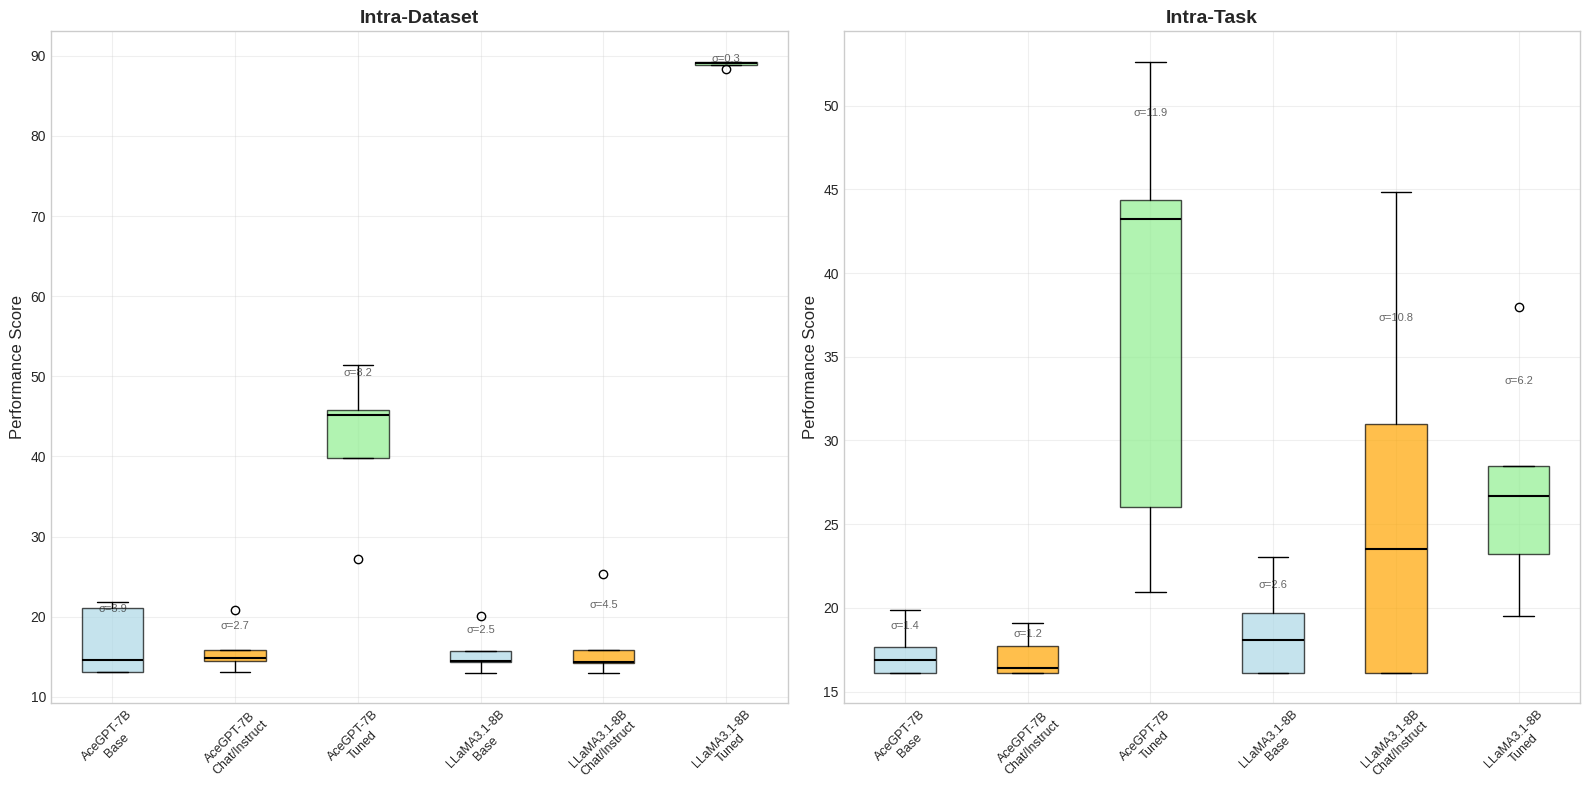

In [20]:
# Generate all plots
# all_plots = generate_all_plots()

# You can also generate individual plots
# nlu_comp = create_boxplot_comparison('NLU', data['NLU'])
nlu_sens = create_combined_sensitivity_plot('Dialect_ID', data['Dialect_ID'])

print("All plots generated successfully!")
print("Files saved as PDF for high-quality paper inclusion.")


In [8]:
# Additional function to create a summary comparison across all tasks
def create_task_comparison_summary(figsize=(20, 12)):
    """Create a comprehensive summary comparing all tasks"""
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Performance Summary Across All Tasks: Intra-Dataset vs Intra-Task', 
                 fontsize=18, fontweight='bold', y=0.95)
    
    task_names = list(data.keys())
    
    for idx, (task_name, task_data) in enumerate(data.items()):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        # Calculate improvement from Base to Tuned for both conditions
        improvements_intra = []
        improvements_cross = []
        
        for model in ['AceGPT-7B', 'LLaMA3.1-8B']:
            # Intra-dataset improvement
            base_intra = np.mean(task_data['intra_dataset'][model]['Base'])
            tuned_intra = np.mean(task_data['intra_dataset'][model]['Tuned'])
            improvements_intra.append(tuned_intra - base_intra)
            
            # Intra-task improvement
            base_cross = np.mean(task_data['intra_task'][model]['Base'])
            tuned_cross = np.mean(task_data['intra_task'][model]['Tuned'])
            improvements_cross.append(tuned_cross - base_cross)
        
        # Create grouped bar plot
        x = np.arange(2)
        width = 0.35
        
        bars1 = ax.bar(x - width/2, improvements_intra, width, 
                      label='Intra-Dataset', alpha=0.8, color='skyblue')
        bars2 = ax.bar(x + width/2, improvements_cross, width, 
                      label='Intra-Task', alpha=0.8, color='lightcoral')
        
        ax.set_title(task_name, fontsize=12, fontweight='bold')
        ax.set_ylabel('Performance Improvement\n(Tuned - Base)', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(['AceGPT-7B', 'LLaMA3.1-8B'])
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    return fig

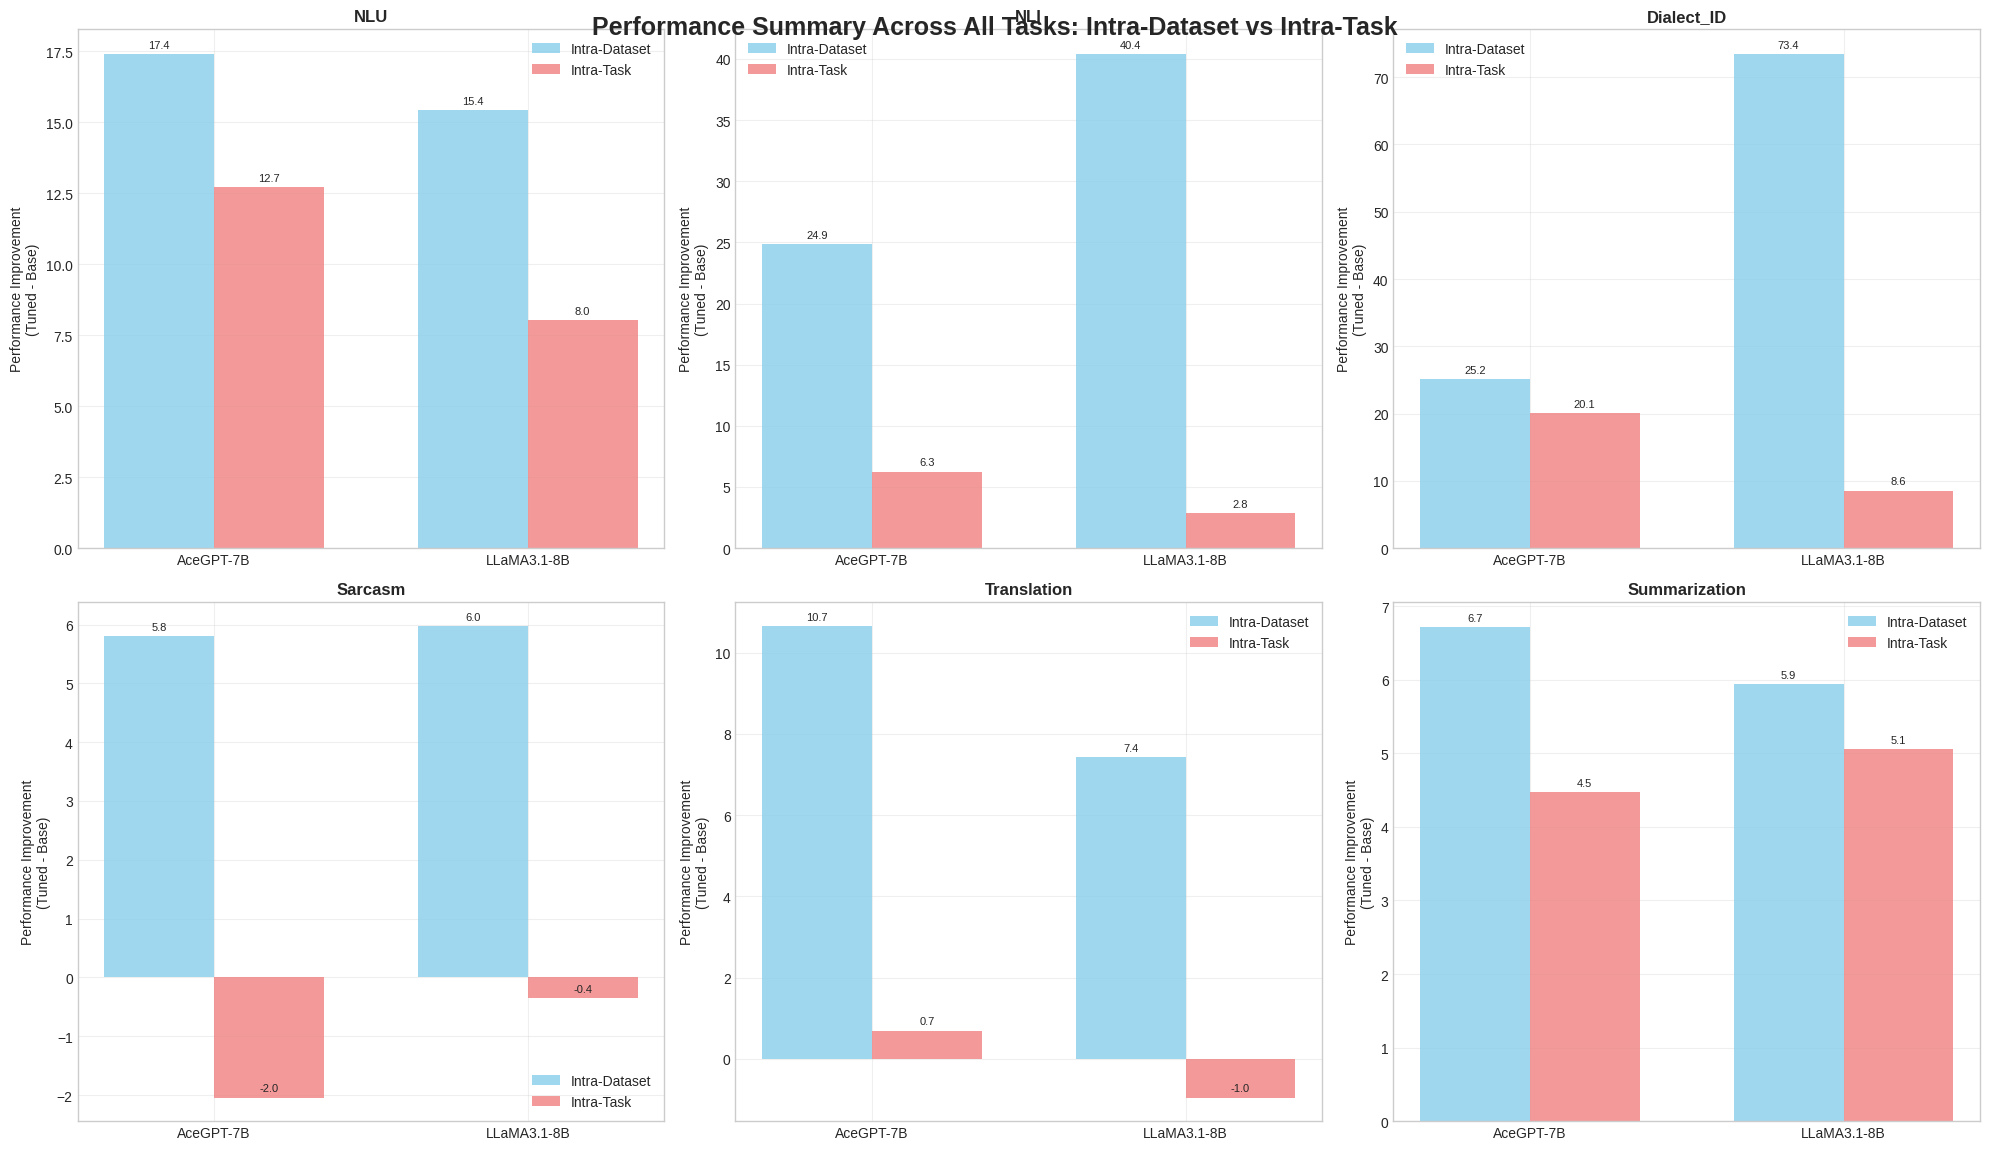

In [ ]:
# Generate the summary plot
summary_plot = create_task_comparison_summary()
# summary_plot.savefig('task_comparison_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()